In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from utils import plot_first_image_from_batch
import os
import time
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import lightning as L
import lightning.pytorch as pl

torch.set_float32_matmul_precision('medium')

log_level: TRACE
dirs:
  root: /home/stud/ath/ath_ws
  output: ${dirs.root}/keypoint_matcher/output
  output_val_images: ${dirs.output}/val_images
  output_test_images: ${dirs.output}/test_images
image_size:
- 520
- 520
patch_size: 32
train:
  images: ${dirs.root}/datasets/euroc/V1_01_easy/mav0/cam0/data
  matches: ${dirs.root}/keypoint_matcher/data/matches/V1_01_easy/matches
  train_batch_size: 2
  val_batch_size: 2
  max_per_image: 5
  max_epochs: 5
  check_val_every_n_epoch: 1
  num_sanity_val_steps: 1
  log_every_n_steps: 25
  accumulate_grad_batches: 2
  learning_rate: 0.0001
test:
  images: ${dirs.root}/datasets/euroc/V2_01_easy/mav0/cam0/data
  matches: ${dirs.root}/keypoint_matcher/data/matches/V2_01_easy/matches
  batch_size: 2
  max_per_image: 5



# Check Data Module

In [31]:
from dataset import MatchesDataModule
dm = MatchesDataModule()
dm.setup(stage='fit')

INFO     | setup | Train Dataset       : 30 samples
INFO     | setup | Validation Dataset  : 20 samples


In [32]:
dl = dm.train_dataloader()
batch = next(iter(dl))

left_coords, right_coords, reference_patches, target_patches = batch
print(left_coords.shape, right_coords.shape)
print(reference_patches.shape, target_patches.shape)

torch.Size([2, 5, 2]) torch.Size([2, 5, 2])
torch.Size([2, 5, 1, 32, 32]) torch.Size([2, 5, 1, 32, 32])


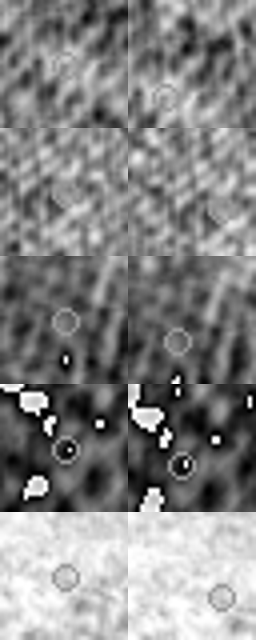

In [33]:
plot_first_image_from_batch(reference_patches, target_patches)

# Check Descriptor Model

In [34]:
if torch.cuda.is_available():
    reference_patches = reference_patches.cuda()
    target_patches = target_patches.cuda()

In [43]:
from model import KeypointDescriptorModel
model = KeypointDescriptorModel()

if torch.cuda.is_available():
    model = model.cuda()

In [39]:
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_trainable_params

593504

In [46]:
start_time = time.time()
reference_embeddings = model(reference_patches)
end_time = time.time()

print(f"Time taken for forward pass: {end_time - start_time:.6f} seconds")

start_time = time.time()
target_embeddings = model(target_patches)
end_time = time.time()

print(f"Time taken for forward pass: {end_time - start_time:.6f} seconds")

DEBUG    | forward | Input shape: torch.Size([2, 5, 1, 32, 32])
DEBUG    | forward | After Reshape : torch.Size([10, 1, 32, 32])
DEBUG    | forward | After ResidualBlock 1 : torch.Size([10, 32, 32, 32])
DEBUG    | forward | After ResidualBlock 2 : torch.Size([10, 64, 32, 32])
DEBUG    | forward | After ResidualBlock 3 : torch.Size([10, 128, 32, 32])
DEBUG    | forward | After ResidualBlock 4 : torch.Size([10, 128, 32, 32])
DEBUG    | forward | After Reshape : torch.Size([2, 5, 128, 32, 32])
Time taken for forward pass: 0.016730 seconds
DEBUG    | forward | Input shape: torch.Size([2, 5, 1, 32, 32])
DEBUG    | forward | After Reshape : torch.Size([10, 1, 32, 32])
DEBUG    | forward | After ResidualBlock 1 : torch.Size([10, 32, 32, 32])
DEBUG    | forward | After ResidualBlock 2 : torch.Size([10, 64, 32, 32])
DEBUG    | forward | After ResidualBlock 3 : torch.Size([10, 128, 32, 32])
DEBUG    | forward | After ResidualBlock 4 : torch.Size([10, 128, 32, 32])
DEBUG    | forward | After Resh

# Check Matcher

In [94]:
from model import KeypointMatcherModel
model = KeypointMatcherModel()

In [89]:
reference_descriptors = model.get_corresponding_descriptors(reference_embeddings, left_coords)
reference_descriptors.shape

torch.Size([2, 5, 128])

In [90]:
target_descriptors = model.get_corresponding_descriptors(target_embeddings, right_coords)
target_descriptors.shape

torch.Size([2, 5, 128])

In [95]:
target_flat = model.flatten_embeddings(target_embeddings)
target_flat.shape

torch.Size([2, 5, 128, 1024])

In [106]:
ref_expanded = reference_descriptors.unsqueeze(-1)      

distances = torch.sqrt(torch.sum((ref_expanded - target_flat) ** 2, dim=2)) 
print(distances.shape)

best_match_indices = torch.argmin(distances, dim=-1)  
print(best_match_indices.shape)

print(best_match_indices)

torch.Size([2, 5, 1024])
torch.Size([2, 5])
tensor([[777, 663, 684, 653, 695],
        [404, 435, 662, 104, 466]], device='cuda:0')


In [110]:

batch_indices = torch.arange(2).view(-1, 1, 1) 
patch_indices = torch.arange(5).view(1, -1, 1)  
channel_indices = torch.arange(target_flat.size(2)).view(1, 1, -1)

best_matching_descriptors = target_flat[
    batch_indices,                              
    patch_indices,                              
    channel_indices,                            
    best_match_indices.unsqueeze(-1)            
] 

best_matching_descriptors.shape

torch.Size([2, 5, 128])

In [115]:
x = model.match_keypoint(reference_embeddings, target_embeddings, left_coords)
best_match_indices, best_matching_descriptors = x

In [119]:
height, width = target_embeddings.shape[-2], target_embeddings.shape[-1]
closest_row = best_match_indices // width
closest_col = best_match_indices % width

closest_coords = torch.stack((closest_row, closest_col), dim=-1)
closest_coords.shape

torch.Size([2, 5, 2])

In [120]:
closest_coords

tensor([[[24,  9],
         [20, 23],
         [21, 12],
         [20, 13],
         [21, 23]],

        [[12, 20],
         [13, 19],
         [20, 22],
         [ 3,  8],
         [14, 18]]], device='cuda:0')